# Day 15: Walk-Forward Modeling

This notebook trains Linear Regression, Random Forest, Gradient Boosting, and a two-stage no-event-aware model using walk-forward validation. Missing feature values are median-imputed inside each fold using the training data only. The modeling matrix also includes province one-hot features and missing-value indicators.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

cwd = Path.cwd()
root = cwd if (cwd / 'src').exists() else cwd.parent
sys.path.insert(0, str(root / 'src'))

from feature_engineering import compute_all_features, event_based_generator, leakage_audit
from two_stage_model import TwoStageMagnitudeModel

data_path = root / 'data' / 'processed' / 'Davao_Earthquakes_with_Dist.csv'
output_dir = root / 'outputs'
output_dir.mkdir(exist_ok=True)

data_path

PosixPath('/home/jshu/SeismoGuard/data/processed/Davao_Earthquakes_with_Dist.csv')

## Load Events

In [2]:
events = pd.read_csv(data_path)
events['province'] = (
    events['location']
    .astype(str)
    .str.extract(r'\(([^)]+)\)')[0]
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
events = events.dropna(subset=['province'])

province_map = {
    'Davao del Norte': 'Davao Del Norte',
    'Davao del Sur': 'Davao Del Sur',
    'Island Garden City of Samal': 'Island Garden City Of Samal',
    'Municipality of Sarangani': 'Municipality Of Sarangani',
}
valid_provinces = [
    'Davao De Oro',
    'Davao Del Norte',
    'Davao Del Sur',
    'Davao Occidental',
    'Davao Oriental',
]

events['province'] = events['province'].str.strip().replace(province_map)
events = events[events['province'].isin(valid_provinces)].copy()

events.shape, events['province'].value_counts()

((19910, 8),
 province
 Davao Oriental      10390
 Davao Occidental     6091
 Davao Del Sur        1720
 Davao De Oro         1299
 Davao Del Norte       410
 Name: count, dtype: int64)

## Build Or Load Feature Matrix

In [3]:
x_path = output_dir / 'feature_matrix_X.pkl'
y_path = output_dir / 'target_y.pkl'

if x_path.exists() and y_path.exists():
    X = pd.read_pickle(x_path)
    y = pd.read_pickle(y_path)
else:
    X, y = event_based_generator(
        events_df=events,
        feature_fn=compute_all_features,
        province_col='province',
        datetime_col='datetime',
        magnitude_col='magnitude',
    )
    X.to_pickle(x_path)
    y.to_pickle(y_path)
    X.to_csv(output_dir / 'feature_matrix_X.csv')
    y.to_csv(output_dir / 'target_y.csv')

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Columns:', list(X.columns))
X.isna().sum().sort_values(ascending=False)

X shape: (1980, 17)
y shape: (1980,)
Columns: ['count_1d', 'count_7d', 'count_30d', 'max_mag_7d', 'max_mag_30d', 'mean_depth_30d', 'days_since_m5', 'min_fault_dist_km', 'mean_fault_dist_km_7d', 'pct_near_fault_30d', 'num_clusters_30d', 'largest_cluster_size_30d', 'pct_clustered_30d', 'max_grid_cell_count_30d', 'b_value_180d', 'a_value_180d', 'delta_b_90d']


delta_b_90d                 957
a_value_180d                481
b_value_180d                481
pct_near_fault_30d          417
max_mag_7d                  417
min_fault_dist_km           417
mean_fault_dist_km_7d       417
mean_depth_30d               67
max_mag_30d                  67
count_1d                      0
days_since_m5                 0
count_30d                     0
count_7d                      0
pct_clustered_30d             0
largest_cluster_size_30d      0
num_clusters_30d              0
max_grid_cell_count_30d       0
dtype: int64

## Add Province And Missingness Features

In [4]:
def add_modeling_features(X):
    X_aug = X.copy()

    missing_indicators = X_aug.isna().astype(int)
    missing_indicators.columns = [f'{col}_missing' for col in missing_indicators.columns]

    provinces = X_aug.index.get_level_values('province')
    province_dummies = pd.get_dummies(provinces, prefix='province', dtype=int)
    province_dummies.index = X_aug.index

    return pd.concat([X_aug, missing_indicators, province_dummies], axis=1)


X_model = add_modeling_features(X)
X_model.to_pickle(output_dir / 'feature_matrix_X_model_enhanced.pkl')
X_model.to_pickle(output_dir / 'X_model.pkl')
X_model.to_csv(output_dir / 'feature_matrix_X_model_enhanced.csv')
X_model.to_csv(output_dir / 'X_model.csv')

print('Raw X shape:', X.shape)
print('Enhanced X shape:', X_model.shape)
print('Added columns:', X_model.shape[1] - X.shape[1])
X_model.columns.tolist()

Raw X shape: (1980, 17)
Enhanced X shape: (1980, 39)
Added columns: 22


['count_1d',
 'count_7d',
 'count_30d',
 'max_mag_7d',
 'max_mag_30d',
 'mean_depth_30d',
 'days_since_m5',
 'min_fault_dist_km',
 'mean_fault_dist_km_7d',
 'pct_near_fault_30d',
 'num_clusters_30d',
 'largest_cluster_size_30d',
 'pct_clustered_30d',
 'max_grid_cell_count_30d',
 'b_value_180d',
 'a_value_180d',
 'delta_b_90d',
 'count_1d_missing',
 'count_7d_missing',
 'count_30d_missing',
 'max_mag_7d_missing',
 'max_mag_30d_missing',
 'mean_depth_30d_missing',
 'days_since_m5_missing',
 'min_fault_dist_km_missing',
 'mean_fault_dist_km_7d_missing',
 'pct_near_fault_30d_missing',
 'num_clusters_30d_missing',
 'largest_cluster_size_30d_missing',
 'pct_clustered_30d_missing',
 'max_grid_cell_count_30d_missing',
 'b_value_180d_missing',
 'a_value_180d_missing',
 'delta_b_90d_missing',
 'province_Davao De Oro',
 'province_Davao Del Norte',
 'province_Davao Del Sur',
 'province_Davao Occidental',
 'province_Davao Oriental']

## Leakage Audit

In [5]:
audit = leakage_audit(
    X=X,
    events_df=events,
    feature_fn=compute_all_features,
    province_col='province',
)
mismatches = audit[(~audit['match_full']) | (~audit['match_past'])]
print('Mismatch count:', len(mismatches))
mismatches.head()

Mismatch count: 0


,province,forecast_date,feature,observed,recomputed_full,recomputed_past,match_full,match_past


## Walk-Forward Splits

In [6]:
def make_walk_forward_splits(X, min_train_weeks=104, test_weeks=26):
    dates = pd.Index(X.index.get_level_values('forecast_date').unique()).sort_values()
    splits = []
    start = min_train_weeks

    while start < len(dates):
        train_dates = dates[:start]
        test_dates = dates[start:start + test_weeks]
        if len(test_dates) == 0:
            break

        train_mask = X.index.get_level_values('forecast_date').isin(train_dates)
        test_mask = X.index.get_level_values('forecast_date').isin(test_dates)
        splits.append((train_mask, test_mask, train_dates[-1], test_dates[0], test_dates[-1]))
        start += test_weeks

    return splits

splits = make_walk_forward_splits(X_model)
len(splits), [(s[2], s[3], s[4]) for s in splits]

(13,
 [(Timestamp('2019-12-23 00:00:00+0000', tz='UTC'),
   Timestamp('2019-12-30 00:00:00+0000', tz='UTC'),
   Timestamp('2020-06-22 00:00:00+0000', tz='UTC')),
  (Timestamp('2020-06-22 00:00:00+0000', tz='UTC'),
   Timestamp('2020-06-29 00:00:00+0000', tz='UTC'),
   Timestamp('2020-12-21 00:00:00+0000', tz='UTC')),
  (Timestamp('2020-12-21 00:00:00+0000', tz='UTC'),
   Timestamp('2020-12-28 00:00:00+0000', tz='UTC'),
   Timestamp('2021-06-21 00:00:00+0000', tz='UTC')),
  (Timestamp('2021-06-21 00:00:00+0000', tz='UTC'),
   Timestamp('2021-06-28 00:00:00+0000', tz='UTC'),
   Timestamp('2021-12-20 00:00:00+0000', tz='UTC')),
  (Timestamp('2021-12-20 00:00:00+0000', tz='UTC'),
   Timestamp('2021-12-27 00:00:00+0000', tz='UTC'),
   Timestamp('2022-06-20 00:00:00+0000', tz='UTC')),
  (Timestamp('2022-06-20 00:00:00+0000', tz='UTC'),
   Timestamp('2022-06-27 00:00:00+0000', tz='UTC'),
   Timestamp('2022-12-19 00:00:00+0000', tz='UTC')),
  (Timestamp('2022-12-19 00:00:00+0000', tz='UTC'),
 

## Two-Stage No-Event-Aware Model

The two-stage model first estimates whether an event occurs in the next 7 days, then estimates the conditional maximum magnitude. Its final prediction is `event_probability * conditional_magnitude`, which helps reduce overprediction for province-weeks with no recorded events.

## Train And Evaluate

In [7]:
models = {
    'linear_regression': LinearRegression(),
    'random_forest': RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    ),
    'gradient_boosting': GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.04,
        max_depth=3,
        min_samples_leaf=5,
        random_state=42,
    ),
    'two_stage_expected': TwoStageMagnitudeModel(),
}

metrics = []
prediction_frames = []
importance_frames = []

for fold, (train_mask, test_mask, train_end, test_start, test_end) in enumerate(splits, start=1):
    X_train, X_test = X_model.loc[train_mask], X_model.loc[test_mask]
    y_train, y_test = y.loc[train_mask], y.loc[test_mask]

    for model_name, model in models.items():
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', model),
        ])
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)

        metrics.append({
            'fold': fold,
            'model': model_name,
            'train_end': train_end,
            'test_start': test_start,
            'test_end': test_end,
            'train_rows': len(X_train),
            'test_rows': len(X_test),
            'mae': mean_absolute_error(y_test, preds),
            'rmse': np.sqrt(mean_squared_error(y_test, preds)),
            'r2': r2_score(y_test, preds),
            'zero_week_mae': mean_absolute_error(y_test[y_test == 0], preds[y_test == 0]) if (y_test == 0).any() else np.nan,
            'event_week_mae': mean_absolute_error(y_test[y_test > 0], preds[y_test > 0]) if (y_test > 0).any() else np.nan,
        })

        fitted_model = pipe.named_steps['model']
        if hasattr(fitted_model, 'feature_importances_'):
            importance_frames.append(pd.DataFrame({
                'fold': fold,
                'model': model_name,
                'feature': X_model.columns,
                'importance': fitted_model.feature_importances_,
            }))

        fold_preds = X_test.reset_index()[['province', 'forecast_date']].copy()
        fold_preds['fold'] = fold
        fold_preds['model'] = model_name
        fold_preds['actual'] = y_test.to_numpy()
        fold_preds['prediction'] = preds
        prediction_frames.append(fold_preds)

metrics_df = pd.DataFrame(metrics)
predictions_df = pd.concat(prediction_frames, ignore_index=True)
feature_importances_df = pd.concat(importance_frames, ignore_index=True)

metrics_df.to_csv(output_dir / 'walk_forward_metrics.csv', index=False)
metrics_df.to_csv(output_dir / 'walk_forward_metrics_enhanced.csv', index=False)
metrics_df.to_csv(output_dir / 'metrics.csv', index=False)
predictions_df.to_csv(output_dir / 'walk_forward_predictions.csv', index=False)
predictions_df.to_csv(output_dir / 'walk_forward_predictions_enhanced.csv', index=False)
predictions_df.to_csv(output_dir / 'preds.csv', index=False)
feature_importances_df.to_csv(output_dir / 'feature_importances_by_fold.csv', index=False)
feature_importances_df.to_csv(output_dir / 'feature_importances_by_fold_enhanced.csv', index=False)
feature_importances_df.to_csv(output_dir / 'fi_folds.csv', index=False)

metrics_df

,fold,model,train_end,test_start,test_end,train_rows,test_rows,mae,rmse,r2,zero_week_mae,event_week_mae
0,1,linear_regression,2019-12-23 00:00:00+00:00,2019-12-30 00:00:00+00:00,2020-06-22 00:00:00+00:00,403,126,0.794674,1.081520,0.662926,1.209999,0.641185
1,1,random_forest,2019-12-23 00:00:00+00:00,2019-12-30 00:00:00+00:00,2020-06-22 00:00:00+00:00,403,126,0.770375,0.979461,0.723541,0.775323,0.768547
2,1,gradient_boosting,2019-12-23 00:00:00+00:00,2019-12-30 00:00:00+00:00,2020-06-22 00:00:00+00:00,403,126,0.896734,1.130665,0.631596,0.949980,0.877057
3,1,two_stage_expected,2019-12-23 00:00:00+00:00,2019-12-30 00:00:00+00:00,2020-06-22 00:00:00+00:00,403,126,0.701717,0.933459,0.748900,0.601897,0.738607
4,2,linear_regression,2020-06-22 00:00:00+00:00,2020-06-29 00:00:00+00:00,2020-12-21 00:00:00+00:00,529,130,0.854372,1.168150,0.553594,1.290828,0.729053
5,2,random_forest,2020-06-22 00:00:00+00:00,2020-06-29 00:00:00+00:00,2020-12-21 00:00:00+00:00,529,130,0.985138,1.303018,0.444565,1.267476,0.904071
6,2,gradient_boosting,2020-06-22 00:00:00+00:00,2020-06-29 00:00:00+00:00,2020-12-21 00:00:00+00:00,529,130,0.978461,1.266076,0.475612,1.278866,0.892207
7,2,two_stage_expected,2020-06-22 00:00:00+00:00,2020-06-29 00:00:00+00:00,2020-12-21 00:00:00+00:00,529,130,0.859310,1.168361,0.553433,1.107710,0.787988
8,3,linear_regression,2020-12-21 00:00:00+00:00,2020-12-28 00:00:00+00:00,2021-06-21 00:00:00+00:00,659,130,0.925654,1.253632,0.489899,1.545774,0.763098
9,3,random_forest,2020-12-21 00:00:00+00:00,2020-12-28 00:00:00+00:00,2021-06-21 00:00:00+00:00,659,130,0.996072,1.264898,0.480690,1.370026,0.898046


## Feature Importances

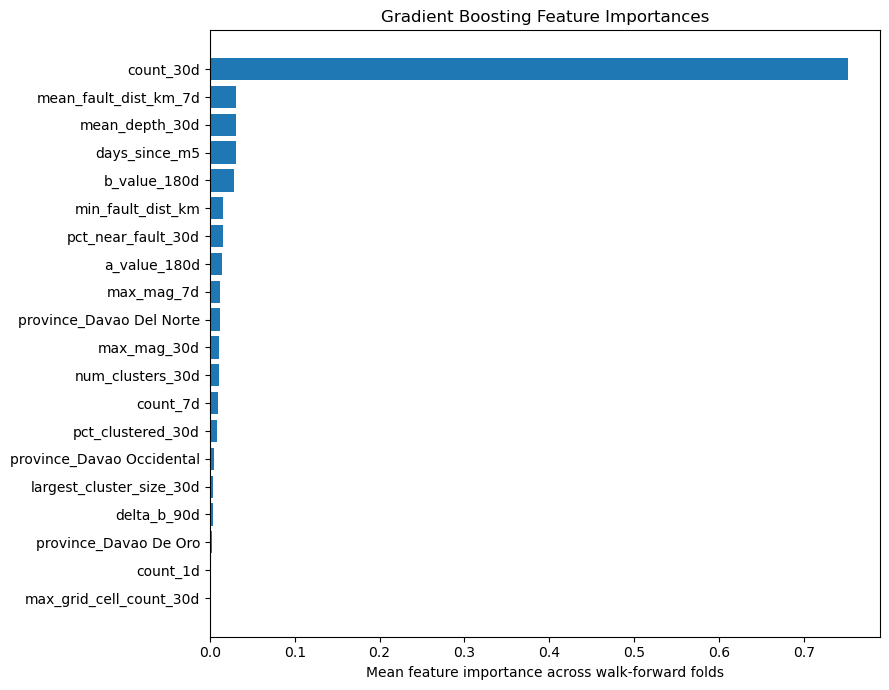

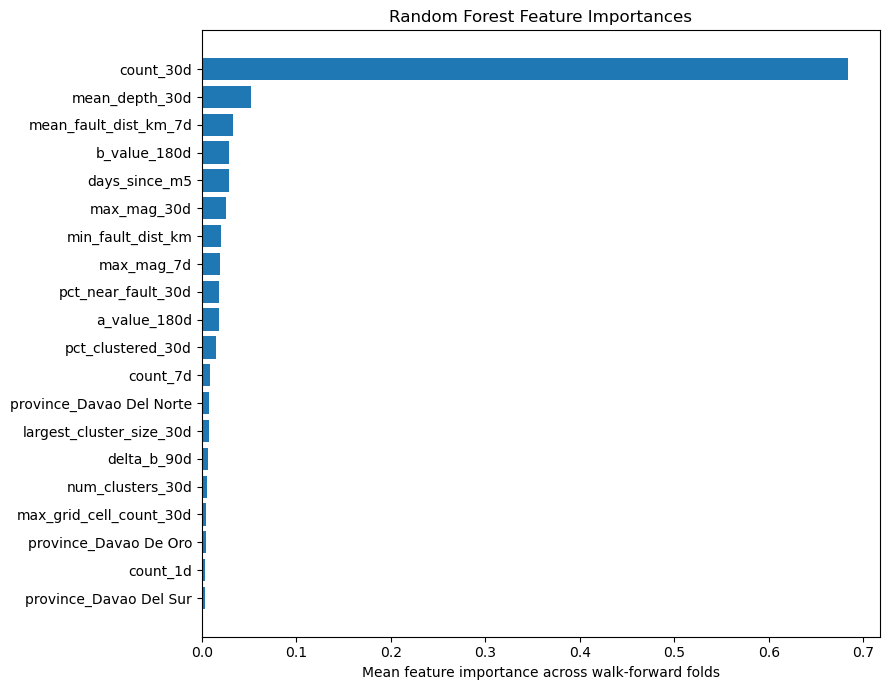

,model,feature,mean,std
6,gradient_boosting,count_30d,0.751953,0.039430
24,gradient_boosting,mean_fault_dist_km_7d,0.031232,0.012768
22,gradient_boosting,mean_depth_30d,0.031037,0.006476
10,gradient_boosting,days_since_m5,0.030594,0.021711
2,gradient_boosting,b_value_180d,0.028347,0.007652
...,...,...,...,...
50,random_forest,days_since_m5_missing,0.000000,0.000000
54,random_forest,largest_cluster_size_30d_missing,0.000000,0.000000
56,random_forest,max_grid_cell_count_30d_missing,0.000000,0.000000
68,random_forest,num_clusters_30d_missing,0.000000,0.000000


In [8]:
importance_summary = (
    feature_importances_df
    .groupby(['model', 'feature'])['importance']
    .agg(['mean', 'std'])
    .reset_index()
    .sort_values(['model', 'mean'], ascending=[True, False])
)
importance_summary.to_csv(output_dir / 'feature_importance_summary.csv', index=False)
importance_summary.to_csv(output_dir / 'feature_importance_summary_enhanced.csv', index=False)
importance_summary.to_csv(output_dir / 'fi_summary.csv', index=False)

for model_name, model_importances in importance_summary.groupby('model'):
    plot_df = model_importances.sort_values('mean', ascending=True).tail(20)
    plt.figure(figsize=(9, 7))
    plt.barh(plot_df['feature'], plot_df['mean'])
    plt.xlabel('Mean feature importance across walk-forward folds')
    plt.title(f'{model_name.replace("_", " ").title()} Feature Importances')
    plt.tight_layout()
    plt.savefig(output_dir / f'{model_name}_feature_importances.png', dpi=150)
    plt.savefig(output_dir / f'{model_name}_feature_importances_enhanced.png', dpi=150)
    plt.show()

importance_summary

## Summary

In [9]:
summary = (
    metrics_df
    .groupby('model')[['mae', 'rmse', 'r2']]
    .agg(['mean', 'std'])
    .round(4)
)
summary.to_csv(output_dir / 'walk_forward_summary.csv')
summary.to_csv(output_dir / 'walk_forward_summary_enhanced.csv')
summary.to_csv(output_dir / 'summary.csv')
summary

mae            rmse              r2        
                      mean     std    mean     std    mean     std
model                                                             
gradient_boosting   0.9491  0.0941  1.2374  0.1261  0.4043  0.1332
linear_regression   0.8984  0.0822  1.1750  0.1054  0.4642  0.1040
random_forest       0.9282  0.0989  1.2005  0.1243  0.4363  0.1315
two_stage_expected  0.9112  0.1016  1.1775  0.1209  0.4534  0.1467